# Ajuste de Hiperparâmetros - Otimização de Modelos

Este notebook realiza o ajuste de hiperparâmetros dos melhores modelos usando GridSearchCV.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
from sqlalchemy import create_engine
import os
import matplotlib.pyplot as plt
import warnings
import boto3
from botocore.client import Config
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI', 'http://mlflow:5000'))
mlflow.set_experiment('diabetes_classification_optimized')

# Configurar boto3 e credenciais AWS para MLFlow salvar modelos no MinIO
try:
    # Configurar variáveis de ambiente para MLFlow
    os.environ['AWS_ACCESS_KEY_ID'] = os.getenv('AWS_ACCESS_KEY_ID', 'minioadmin')
    os.environ['AWS_SECRET_ACCESS_KEY'] = os.getenv('AWS_SECRET_ACCESS_KEY', 'minioadmin')
    os.environ['MLFLOW_S3_ENDPOINT_URL'] = os.getenv('MLFLOW_S3_ENDPOINT_URL', 'http://minio:9000')
    
    # Configurar cliente S3 para MinIO
    s3_endpoint = os.getenv('MLFLOW_S3_ENDPOINT_URL', 'http://minio:9000')
    s3_client = boto3.client(
        's3',
        endpoint_url=s3_endpoint,
        aws_access_key_id=os.environ['AWS_ACCESS_KEY_ID'],
        aws_secret_access_key=os.environ['AWS_SECRET_ACCESS_KEY'],
        config=Config(signature_version='s3v4'),
        region_name='us-east-1'
    )
    print("✅ Boto3 e credenciais AWS configuradas para MLFlow/MinIO")
except Exception as e:
    print(f"⚠️ Aviso ao configurar boto3: {e}")

POSTGRES_HOST = os.getenv('POSTGRES_HOST', 'postgres')
POSTGRES_PORT = os.getenv('POSTGRES_PORT', '5432')
POSTGRES_USER = os.getenv('POSTGRES_USER', 'postgres')
POSTGRES_PASSWORD = os.getenv('POSTGRES_PASSWORD', 'postgres')
POSTGRES_DB = os.getenv('POSTGRES_DB', 'diabetes_db')

DATABASE_URL = f"postgresql://{POSTGRES_USER}:{POSTGRES_PASSWORD}@{POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}"
engine = create_engine(DATABASE_URL)

query = "SELECT * FROM diabetes_processed"
df = pd.read_sql(query, engine)
print(f"Dataset carregado: {df.shape}")


✅ Boto3 e credenciais AWS configuradas para MLFlow/MinIO
Dataset carregado: (3000, 16)


## Preparação dos Dados


In [2]:
# Preparar features e target
feature_cols = ['age', 'urea', 'creatinine', 'hba1c', 'cholesterol', 
                'triglycerides', 'hdl', 'ldl', 'vldl', 'bmi']

le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])
feature_cols.append('gender_encoded')

X = df[feature_cols].copy()
y = df['class_label'].copy()

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Dividir dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balancear
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Treino balanceado: {X_train_balanced.shape}")
print(f"Teste: {X_test_scaled.shape}")


Treino balanceado: (6078, 11)
Teste: (600, 11)


## Ajuste de Hiperparâmetros - Random Forest


In [3]:
print("=" * 60)
print("AJUSTE DE HIPERPARÂMETROS - RANDOM FOREST")
print("=" * 60)

# Grid de parâmetros (reduzido para ser mais rápido)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search_rf = GridSearchCV(
    rf_base, param_grid_rf, cv=5, scoring='f1_weighted', 
    n_jobs=-1, verbose=1
)

print("\nIniciando busca de hiperparâmetros...")
grid_search_rf.fit(X_train_balanced, y_train_balanced)

print(f"\nMelhores parâmetros: {grid_search_rf.best_params_}")
print(f"Melhor score (CV): {grid_search_rf.best_score_:.4f}")

# Avaliar no teste
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\nAccuracy no teste: {accuracy_rf:.4f}")
print(f"F1-Score no teste: {f1_rf:.4f}")

# Registrar no MLFlow
with mlflow.start_run(run_name="Random Forest - Optimized"):
    mlflow.log_params(grid_search_rf.best_params_)
    mlflow.log_metric("accuracy", accuracy_rf)
    mlflow.log_metric("f1_score_weighted", f1_rf)
    mlflow.log_metric("cv_score", grid_search_rf.best_score_)
    mlflow.sklearn.log_model(best_rf, "model")
    mlflow.sklearn.log_model(scaler, "scaler")
    
    print("\n✅ Modelo registrado no MLFlow")


AJUSTE DE HIPERPARÂMETROS - RANDOM FOREST

Iniciando busca de hiperparâmetros...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Melhores parâmetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Melhor score (CV): 0.9997

Accuracy no teste: 1.0000
F1-Score no teste: 1.0000


2025/11/24 18:50:24 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!



✅ Modelo registrado no MLFlow


## Ajuste de Hiperparâmetros - Gradient Boosting


In [4]:
print("=" * 60)
print("AJUSTE DE HIPERPARÂMETROS - GRADIENT BOOSTING")
print("=" * 60)

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb_base = GradientBoostingClassifier(random_state=42)
grid_search_gb = GridSearchCV(
    gb_base, param_grid_gb, cv=5, scoring='f1_weighted',
    n_jobs=-1, verbose=1
)

print("\nIniciando busca de hiperparâmetros...")
grid_search_gb.fit(X_train_balanced, y_train_balanced)

print(f"\nMelhores parâmetros: {grid_search_gb.best_params_}")
print(f"Melhor score (CV): {grid_search_gb.best_score_:.4f}")

# Avaliar no teste
best_gb = grid_search_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test_scaled)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

print(f"\nAccuracy no teste: {accuracy_gb:.4f}")
print(f"F1-Score no teste: {f1_gb:.4f}")

# Registrar no MLFlow
with mlflow.start_run(run_name="Gradient Boosting - Optimized"):
    mlflow.log_params(grid_search_gb.best_params_)
    mlflow.log_metric("accuracy", accuracy_gb)
    mlflow.log_metric("f1_score_weighted", f1_gb)
    mlflow.log_metric("cv_score", grid_search_gb.best_score_)
    mlflow.sklearn.log_model(best_gb, "model")
    mlflow.sklearn.log_model(scaler, "scaler")
    
    print("\n✅ Modelo registrado no MLFlow")


AJUSTE DE HIPERPARÂMETROS - GRADIENT BOOSTING

Iniciando busca de hiperparâmetros...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Melhores parâmetros: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100}
Melhor score (CV): 0.9997

Accuracy no teste: 1.0000
F1-Score no teste: 1.0000


2025/11/24 18:51:15 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!



✅ Modelo registrado no MLFlow


## Comparação: Antes vs Depois da Otimização


RESULTADOS DOS MODELOS OTIMIZADOS
                               Accuracy  F1-Score
Random Forest (Otimizado)           1.0       1.0
Gradient Boosting (Otimizado)       1.0       1.0


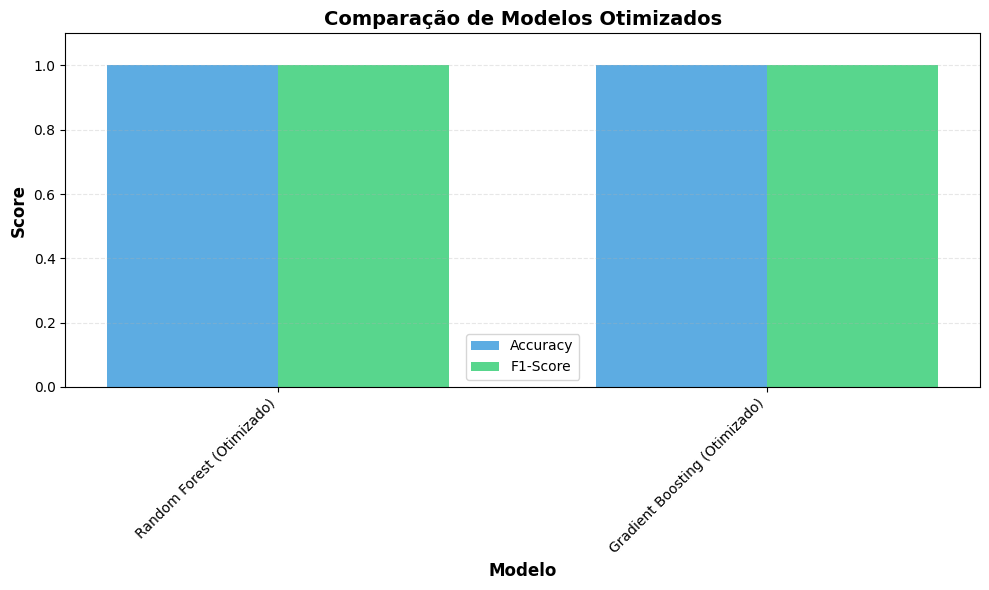


✅ Gráfico salvo em reports/optimized_models_comparison.png


In [5]:
# Comparar modelos otimizados
results_optimized = {
    'Random Forest (Otimizado)': {'accuracy': accuracy_rf, 'f1': f1_rf},
    'Gradient Boosting (Otimizado)': {'accuracy': accuracy_gb, 'f1': f1_gb}
}

results_df = pd.DataFrame(results_optimized).T
results_df.columns = ['Accuracy', 'F1-Score']

print("=" * 60)
print("RESULTADOS DOS MODELOS OTIMIZADOS")
print("=" * 60)
print(results_df)

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='#3498db', alpha=0.8)
ax.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Modelos Otimizados', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('../reports/optimized_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico salvo em reports/optimized_models_comparison.png")
